Exploratory Data Analysis
1.understanding structure of data
2.assessing data quality(missing values, incorrect value,duplicates)
3.discovering patterns


In [1]:
from symtable import Class

print("Lets do data Analysis using pandas")

Lets do data Analysis using pandas


In [8]:
!pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [9]:
import pandas as pd

print(pd.__version__)

2.3.3


In [11]:
df=pd.read_csv("train.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [12]:
print(df.shape)

(891, 12)


In [13]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [19]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


1. Age record
177 missing age records
177/891~20%
2. about 20% passengers have no age record
3. Cabin:687 missing values
4. over three-quarters of cabin numbers are missing
687/792~77%

In [20]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [26]:
overall_survival_rate = df["Survived"].mean() * 100
print(overall_survival_rate)

38.38383838383838


1.overall survival rate: 38.38%

In [44]:
gender_survival=df.groupby("Sex")["Survived"].mean()*100
print(gender_survival)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


Survival by Gender
1. Female : 74.20%
2. Male : 18.89%

In [39]:
!pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [41]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Survival rate')

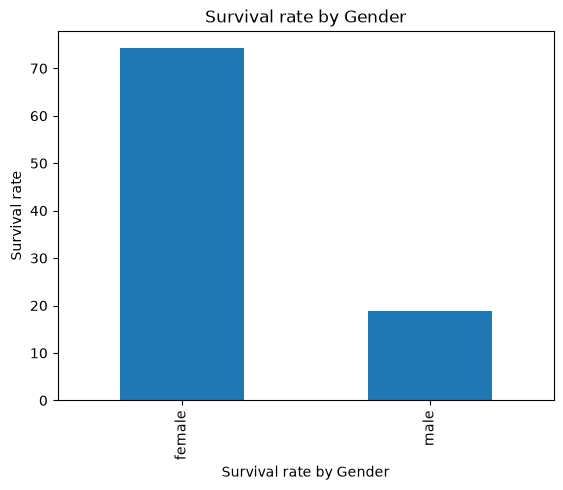

In [47]:
gender_survival.plot(kind="bar")
plt.title("Survival rate by Gender")
plt.xlabel("Survival rate by Gender")
plt.ylabel("Survival rate")

In [46]:
class_survival=df.groupby("Pclass")["Survived"].mean()*100
print(class_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


Survival by Class
1. First Class : highest survival rate
2. Third Class : Lowest survival rate
3. Passenger class associated with survival

Text(0, 0.5, 'Survival rate')

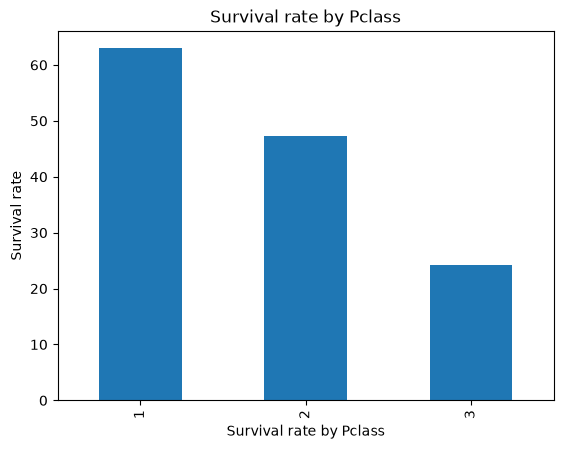

In [48]:
class_survival.plot(kind="bar")
plt.title("Survival rate by Pclass")
plt.xlabel("Survival rate by Pclass")
plt.ylabel("Survival rate")

In [53]:
Average_Age_by_Survival=df.groupby("Survived")["Age"].mean()
print(Average_Age_by_Survival)

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64


Passengers survived were older or younger?
1. Died: 30.63yrs
2. Survived: 28.34yrs
3. Weak Relationship

Text(0, 0.5, 'Survival rate')

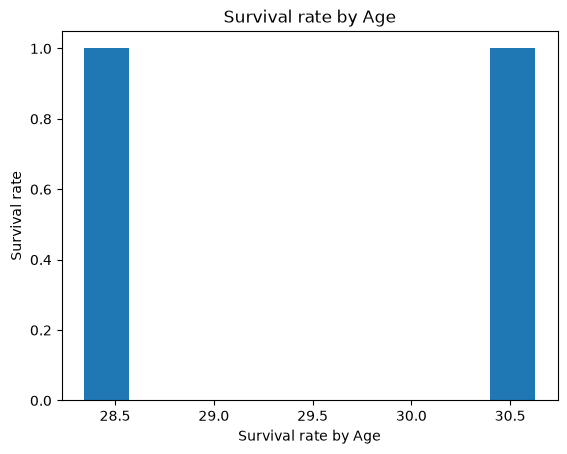

In [54]:
Average_Age_by_Survival.plot(kind="hist")
plt.title("Survival rate by Age")
plt.xlabel("Survival rate by Age")
plt.ylabel("Survival rate")

In [56]:
df["FamilySize"]=df["SibSp"]+df["Parch"]+1
df["FamilySize"].describe()

count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64

In [57]:
Survival_by_Family=df.groupby("FamilySize")["Survived"].mean()*100
print(Survival_by_Family)

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64


Survival by family size
1. Family with 4 members had highest survival rate
2. followed by family size : 3 and family size :2

In [58]:
survival_by_fare=df.groupby("Survived")["Fare"].mean()
print(survival_by_fare)

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


In [61]:
Embarked_survival=df.groupby("Embarked")["Survived"].mean()*100
print(Embarked_survival)

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64
